In [0]:
customers_df = spark.read.csv(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/customers.csv',
    header=True,
    inferSchema=True
)

customers_df.printSchema()
display(customers_df)


root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)



customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


In [0]:
products_df = spark.read.csv(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/products.csv',
    header=True,
    inferSchema=True
)
products_df.printSchema()
display(products_df)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)



product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


In [0]:
orders_df = spark.read.csv(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/orders.csv',
    header=True,
    inferSchema=True
)
orders_df.printSchema()
display(orders_df)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)



order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


In [0]:
preferences_df = spark.read.option(
    "multiLine",
    "true"
).json(
    '/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/customer_preferences.json'
)
preferences_df.printSchema()
display(preferences_df)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


In [0]:
customers_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/bronze/customers')

products_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/bronze/products')

orders_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/bronze/orders')

preferences_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/bronze/customer_preferences')

In [0]:
from pyspark.sql.functions import * 

customers_df.select(*[count(when(col(c).isNull(), c)).alias(c) for c in customers_df.columns]).show()

orders_df.select(*[count(when(col(c).isNull(), c)).alias(c) for c in orders_df.columns]).show()

products_df.select(*[count(when(col(c).isNull(), c)).alias(c) for c in products_df.columns]).show()

preferences_df.select(*[count(when(col(c).isNull(), c)).alias(c) for c in preferences_df.columns]).show()

+-----------+-------------+----+-----+-------------+
|customer_id|customer_name|city|state|customer_type|
+-----------+-------------+----+-----+-------------+
|          0|            0|   0|    0|            0|
+-----------+-------------+----+-----+-------------+

+--------+-----------+----------+----------+--------+------+
|order_id|customer_id|product_id|order_date|quantity|status|
+--------+-----------+----------+----------+--------+------+
|       0|          0|         0|         0|       0|     0|
+--------+-----------+----------+----------+--------+------+

+----------+------------+--------+----------+
|product_id|product_name|category|unit_price|
+----------+------------+--------+----------+
|         0|           0|       0|         0|
+----------+------------+--------+----------+

+-----------+-------+-----------------+
|customer_id|loyalty|preferred_channel|
+-----------+-------+-----------------+
|          0|      0|                0|
+-----------+-------+----------------

In [0]:
flat_df= preferences_df.select(
    'customer_id',
    'preferred_channel',
    col('loyalty.tier').alias('tier'),
    col('loyalty.points').alias('points')
)

flat_df.show()

+-----------+-----------------+--------+------+
|customer_id|preferred_channel|    tier|points|
+-----------+-----------------+--------+------+
|       C101|           Online|    Gold|  1200|
|       C102|            Store|  Silver|   700|
|       C104|           Online|Platinum|  2200|
|       C108|       Mobile App|    Gold|  1500|
+-----------+-----------------+--------+------+



In [0]:
customer_pref = customers_df.join(
    flat_df,
    "customer_id",
    "left"
)
display(customer_pref)

customer_id,customer_name,city,state,customer_type,preferred_channel,tier,points
C101,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


In [0]:
orders_customer = orders_df.join(
    customer_pref,
    "customer_id",
    "left"
)
display(orders_customer)

customer_id,order_id,product_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points
C101,O1001,P101,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,O1002,P102,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,O1003,P103,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,O1004,P104,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,O1005,P105,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,O1006,P106,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,O1007,P107,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,O1008,P108,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500
C101,O1009,P102,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C104,O1010,P101,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200


In [0]:
final_df = orders_customer.join(
    products_df,
    "product_id",
    "left"
)
display(final_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000


In [0]:
final_df = final_df.withColumn(
    'revenue',
    col('quantity') * col('unit_price')
).withColumn(
    'order_month',
    month(col('order_date'))
).withColumn(
    'customer_segment',
    when(col('customer_type') == 'Premium', 'High Value')
    .when(col('customer_type') == 'Regular', 'Standard Value')
    .otherwise('Other')
)

final_df.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|      Laptop|Electronics|     65000|  65000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|   

In [0]:
final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/silver/customer_sales')

In [0]:
customers_df.createOrReplaceTempView("customers")
products_df.createOrReplaceTempView("products")
orders_df.createOrReplaceTempView("orders")
flat_df.createOrReplaceTempView("preferences")
final_df.createOrReplaceTempView("customer_sales")

In [0]:
%sql
SELECT SUM(revenue) AS total_revenue
FROM customer_sales;

total_revenue
336000


In [0]:
%sql
SELECT city, SUM(revenue) AS total_revenue
FROM customer_sales
GROUP BY city
ORDER BY total_revenue DESC;

city,total_revenue
Hyderabad,135000
Delhi,89000
Bangalore,50000
Mumbai,21000
Chennai,18000
Kochi,15000
Pune,8000


In [0]:
%sql
SELECT category, SUM(revenue) AS total_revenue
FROM customer_sales
GROUP BY category
ORDER BY total_revenue DESC;

category,total_revenue
Electronics,250000
Furniture,45000
Fashion,41000


In [0]:
%sql
SELECT customer_id,
    customer_name,
    SUM(revenue) AS total_revenue
FROM customer_sales
GROUP BY customer_id, customer_name
ORDER BY total_revenue DESC
LIMIT 5;

customer_id,customer_name,total_revenue
C101,Rahul Sharma,90000
C104,Sneha Patel,89000
C102,Priya Reddy,50000
C107,Arjun Verma,45000
C103,Amit Kumar,21000


In [0]:
%sql
SELECT *
FROM orders
WHERE status = 'Completed';

order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1004,C104,P104,2026-06-02,2,Completed
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


In [0]:
from pyspark.sql.window import *

product_rev = final_df.groupBy(
    'product_id',
    'product_name'
).agg(
    sum('revenue').alias('total_revenue')
)

win_spec = Window.orderBy(col('total_revenue').desc())

product_rank_df = product_rev.withColumn(
    'rank',
    rank().over(win_spec)
)

product_rank_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+------------+-------------+----+
|product_id|product_name|total_revenue|rank|
+----------+------------+-------------+----+
|      P101|      Laptop|       130000|   1|
|      P102|      Mobile|        75000|   2|
|      P107|          TV|        45000|   3|
|      P104|       Table|        24000|   4|
|      P103|       Chair|        21000|   5|
|      P105|       Shoes|        18000|   6|
|      P108|         Bag|        15000|   7|
|      P106|       Watch|         8000|   8|
+----------+------------+-------------+----+



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
customer_rev = final_df.groupBy(
    'customer_id',
    'customer_name'
).agg(
    sum('revenue').alias('total_revenue')
)

win_spec = Window.orderBy(col('total_revenue').desc())

customer_rank_df = customer_rev.withColumn(
    'rank',
    rank().over(win_spec)
)

customer_rank_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+-------------+----+
|customer_id|customer_name|total_revenue|rank|
+-----------+-------------+-------------+----+
|       C101| Rahul Sharma|        90000|   1|
|       C104|  Sneha Patel|        89000|   2|
|       C102|  Priya Reddy|        50000|   3|
|       C107|  Arjun Verma|        45000|   4|
|       C103|   Amit Kumar|        21000|   5|
|       C105|   Farhan Ali|        18000|   6|
|       C108|   Meera Nair|        15000|   7|
|       C106|   Neha Singh|         8000|   8|
+-----------+-------------+-------------+----+



In [0]:
top_3 = customer_rev.withColumn(
    'rank',
    rank().over(win_spec)
).filter(
    col('rank') <= 3
)

top_3.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+-------------+----+
|customer_id|customer_name|total_revenue|rank|
+-----------+-------------+-------------+----+
|       C101| Rahul Sharma|        90000|   1|
|       C104|  Sneha Patel|        89000|   2|
|       C102|  Priya Reddy|        50000|   3|
+-----------+-------------+-------------+----+



In [0]:
category_product_df = final_df.groupBy(
    'product_name',
    'category'
).agg(
    sum('revenue').alias('total_revenue')
)

win_spec = Window.partitionBy(
    'category'
).orderBy(
    col('total_revenue').desc()
)

top_product_df = category_product_df.withColumn(
    'rank',
    rank().over(win_spec)
).filter(
    col('rank') == 1
)

top_product_df.show()

+------------+-----------+-------------+----+
|product_name|   category|total_revenue|rank|
+------------+-----------+-------------+----+
|      Laptop|Electronics|       130000|   1|
|       Shoes|    Fashion|        18000|   1|
|       Table|  Furniture|        24000|   1|
+------------+-----------+-------------+----+



In [0]:
daily_rev = final_df.groupBy(
    'order_date'
).agg(
    sum('revenue').alias('daily_revenue')
)

win_spec = Window.orderBy(
    'order_date'
).rowsBetween(
    Window.unboundedPreceding,
    Window.currentRow
)

running_revenue_df = daily_rev.withColumn(
    'running_revenue',
    sum('daily_revenue').over(win_spec)
)

running_revenue_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-------------+---------------+
|order_date|daily_revenue|running_revenue|
+----------+-------------+---------------+
|2026-06-01|       115000|         115000|
|2026-06-02|        45000|         160000|
|2026-06-03|        26000|         186000|
|2026-06-04|        60000|         246000|
|2026-06-05|        90000|         336000|
+----------+-------------+---------------+



In [0]:
final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/delta/customer_sales")

delta_data = spark.read.format("delta").load(
    "/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/delta/customer_sales"
)

delta_data.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|      Laptop|Electronics|     65000|  65000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|   

In [0]:
final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("customer_sales_delta")

In [0]:
final_df.createOrReplaceTempView("customer_sales_temp")

In [0]:
%sql
CREATE OR REPLACE TABLE customer_sales_sql_delta
USING DELTA
AS
SELECT *
FROM customer_sales_temp;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT * FROM customer_sales_sql_delta;

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000,6,High Value


In [0]:
%sql describe history customer_sales_delta;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T17:41:04.000Z,141685270976780,azuser7212_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(3440497224893361),becb1b44-72b7-4a0a-8db9-cfb1b7ed7a47,0622-162326-zuw3ht6o-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5975)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
v0_delta = spark.read.format('delta').option('versionAsOf', 0).load('/Volumes/hexa_databricks_7405607626929262/default/hexa_catalog/delta/customer_sales')
v0_delta.show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|preferred_channel|    tier|points|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+-----------------+--------+------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|           Online|    Gold|  1200|      Laptop|Electronics|     65000|  65000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|   

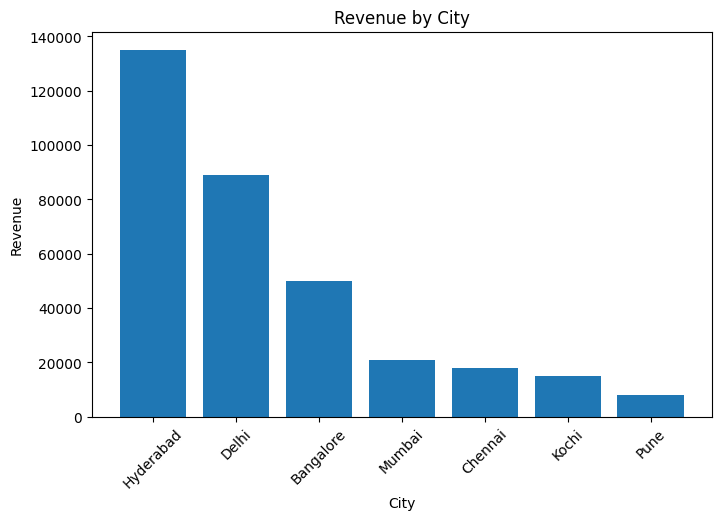

In [0]:
import matplotlib.pyplot as plt
    
city_rev = final_df.groupBy('city') \
    .agg(sum('revenue').alias('total_revenue')) \
    .orderBy(desc('total_revenue'))

city_rev = city_rev.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_rev['city'], city_rev['total_revenue'])
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.xticks(rotation=45)
plt.show()

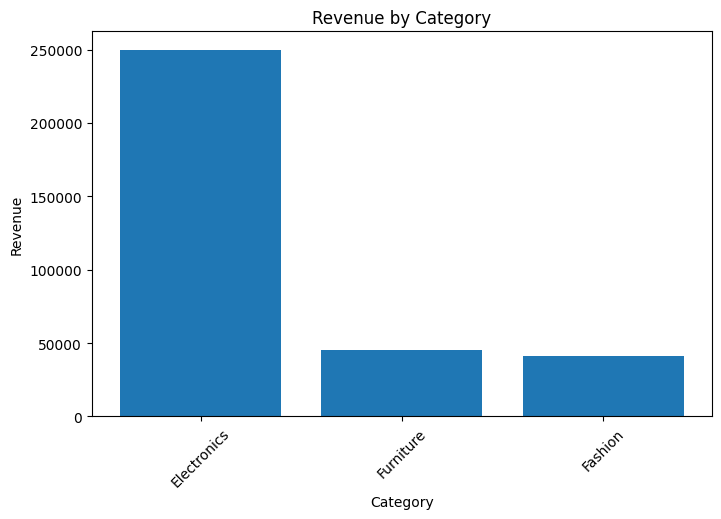

In [0]:
category_rev = final_df.groupBy('category') \
    .agg(sum('revenue').alias('total_revenue')) \
    .orderBy(desc('total_revenue'))

category_rev = category_rev.toPandas()

plt.figure(figsize=(8,5))
plt.bar(category_rev['category'], category_rev['total_revenue'])
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Revenue by Category')
plt.xticks(rotation=45)
plt.show()

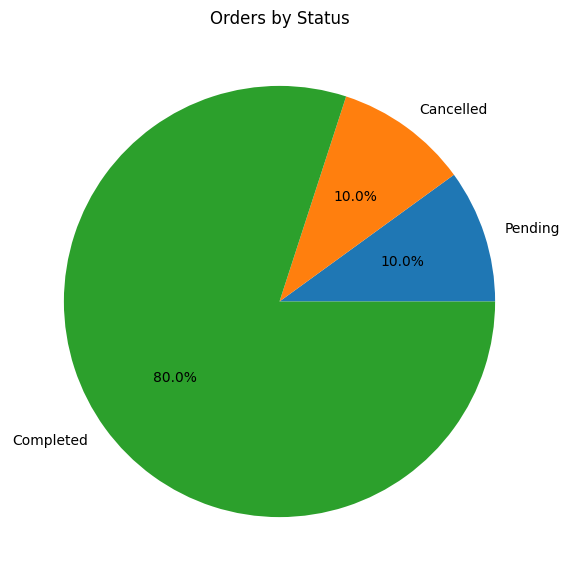

In [0]:
status_df = final_df.groupBy('status').count()

status_df = status_df.toPandas()

plt.figure(figsize=(7,7))
plt.pie(
    status_df['count'],
    labels=status_df['status'],
    autopct='%1.1f%%'
)
plt.title('Orders by Status')
plt.show()

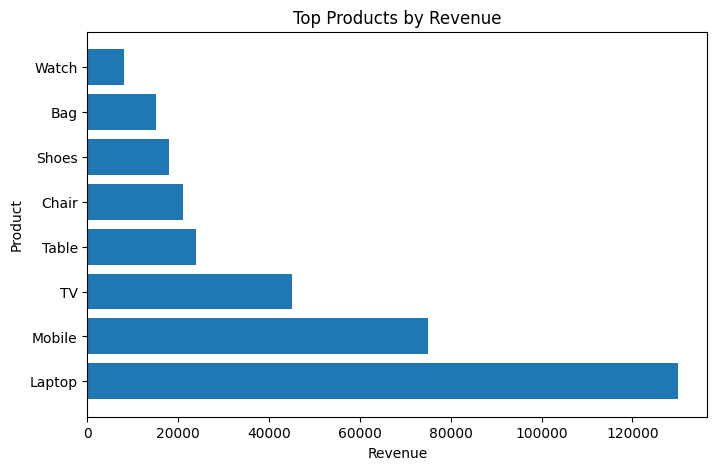

In [0]:
top_products = final_df.groupBy(
    'product_name'
).agg(
    sum('revenue').alias('total_revenue')
).orderBy(desc('total_revenue'))

top_products = top_products.toPandas()

plt.figure(figsize=(8,5))
plt.barh(
    top_products['product_name'],
    top_products['total_revenue']
)
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Top Products by Revenue')
plt.show()

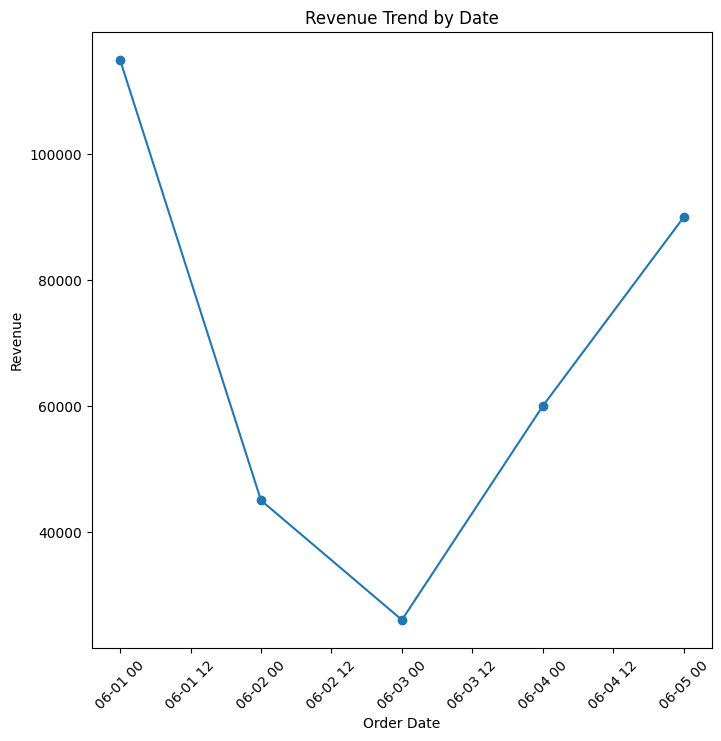

In [0]:
trend = final_df.groupBy(
    'order_date'
).agg(
    sum('revenue').alias('daily_revenue')
).orderBy('order_date')

trend = trend.toPandas()

plt.figure(figsize=(8,8))
plt.plot(
    trend['order_date'],
    trend['daily_revenue'],
    marker='o'
)
plt.xlabel('Order Date')
plt.ylabel('Revenue')
plt.title('Revenue Trend by Date')
plt.xticks(rotation=45)

plt.show()

In [0]:
final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("customer_managed")

In [0]:
%sql
SELECT * FROM customer_managed;

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,preferred_channel,tier,points,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,null,null,null,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200,Laptop,Electronics,65000,65000,6,High Value


In [0]:
final_df.createOrReplaceTempView("customer_temp")  

In [0]:
%sql
CREATE OR REPLACE TABLE customer_external
USING DELTA
AS
SELECT *
FROM customer_temp;

num_affected_rows,num_inserted_rows


In [0]:
%sql describe history customer_sales_delta;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T17:41:04.000Z,141685270976780,azuser7212_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(3440497224893361),becb1b44-72b7-4a0a-8db9-cfb1b7ed7a47,0622-162326-zuw3ht6o-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5975)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql 

optimize customer_sales_delta;
optimize customer_sales_delta
zorder by city;
vacuum customer_sales_delta;

path
""


In [0]:
customers_df.printSchema()
orders_df.printSchema()
products_df.printSchema()
preferences_df.printSchema()
final_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_dat